<a href="https://colab.research.google.com/github/dipeshpadole786/CodeSoft-Tasks-DipeshPadole786/blob/main/Task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Churn Prediction

## Objective
Predict whether a customer will leave the bank (Exited = 1) or stay (Exited = 0) using customer demographic and account information.

## 1. Setup and Imports
This section handles the installation of necessary libraries and imports all the modules required for the project.

In [20]:
import sklearn
import pandas
import numpy
import matplotlib
import seaborn
import joblib
import openpyxl

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


import warnings
warnings.filterwarnings('ignore')

## 2. Data Loading and Initial Exploration
This section focuses on loading the dataset and performing initial checks to understand its structure and content.

In [3]:
try:
    df = pd.read_csv('Churn_Modelling.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: 'Churn_Modelling.csv' not found. Please upload the file or mount Google Drive.")

    df = pd.DataFrame()

print(f"\nDataset shape: {df.shape}")

print("\nColumn information:")
df.info()

print("\nFirst 5 records of the dataset:")
display(df.head())

print("\nMissing values per column:")
display(df.isnull().sum())

print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")

print("\nDescriptive statistics for numerical columns:")
display(df.describe())

Dataset loaded successfully.

Dataset shape: (10000, 14)

Column information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB

First 5 records

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0



Missing values per column:


,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0



Number of duplicate rows: 0

Descriptive statistics for numerical columns:


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


## 3. Exploratory Data Analysis (EDA)
This section involves visualizing the data to understand distributions, relationships, and potential patterns related to customer churn.

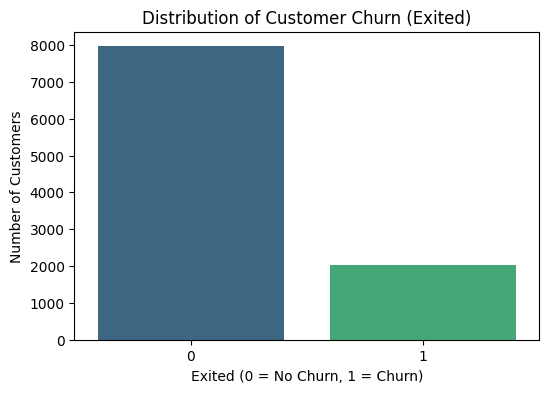


Churn Percentage:
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64
Approximately 20.37% of customers have churned.


In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Exited', data=df, palette='viridis')
plt.title('Distribution of Customer Churn (Exited)')
plt.xlabel('Exited (0 = No Churn, 1 = Churn)')
plt.ylabel('Number of Customers')
plt.show()

churn_percentage = df['Exited'].value_counts(normalize=True) * 100
print("\nChurn Percentage:")
print(churn_percentage)
print(f"Approximately {churn_percentage[1]:.2f}% of customers have churned.")

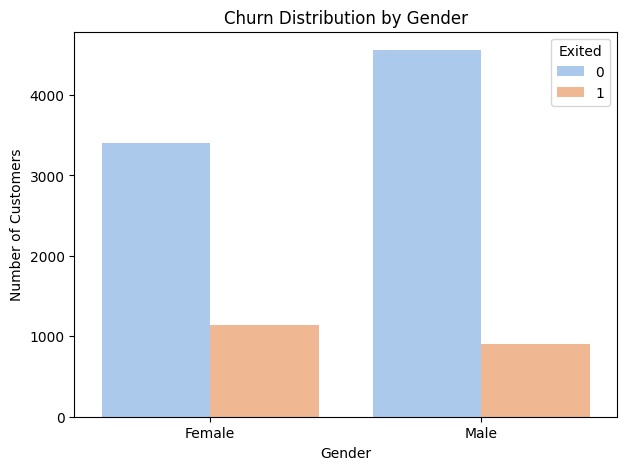


Churn rate by Gender:


,Exited
Gender,
Female,25.07
Male,16.46


In [5]:
plt.figure(figsize=(7, 5))
sns.countplot(x='Gender', hue='Exited', data=df, palette='pastel')
plt.title('Churn Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.show()

print("\nChurn rate by Gender:")
display(df.groupby('Gender')['Exited'].mean().mul(100).round(2))

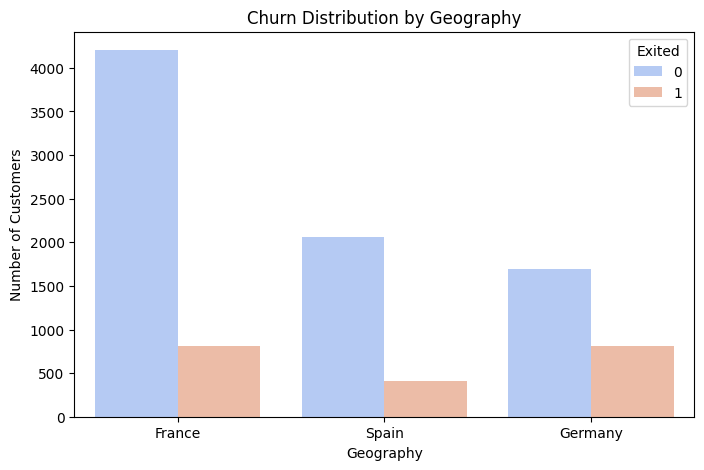


Churn rate by Geography:


,Exited
Geography,
France,16.15
Germany,32.44
Spain,16.67


In [6]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Geography', hue='Exited', data=df, palette='coolwarm')
plt.title('Churn Distribution by Geography')
plt.xlabel('Geography')
plt.ylabel('Number of Customers')
plt.show()

print("\nChurn rate by Geography:")
display(df.groupby('Geography')['Exited'].mean().mul(100).round(2))

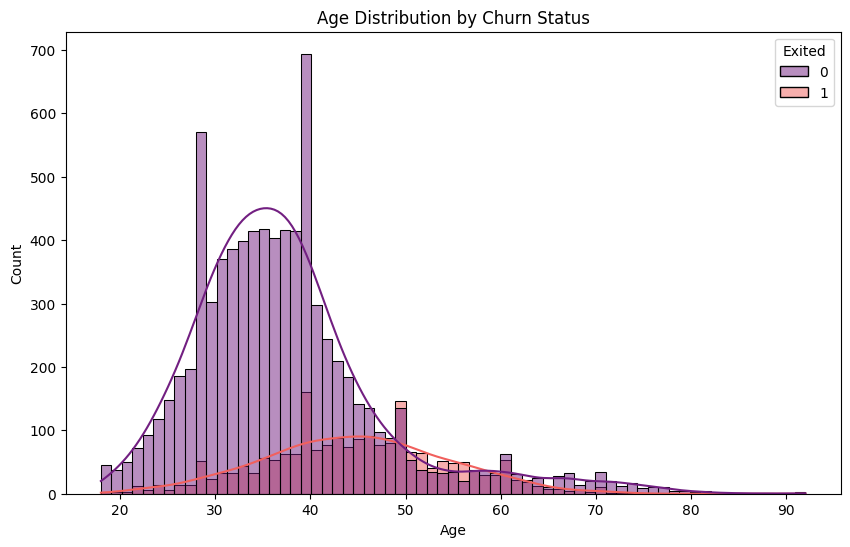

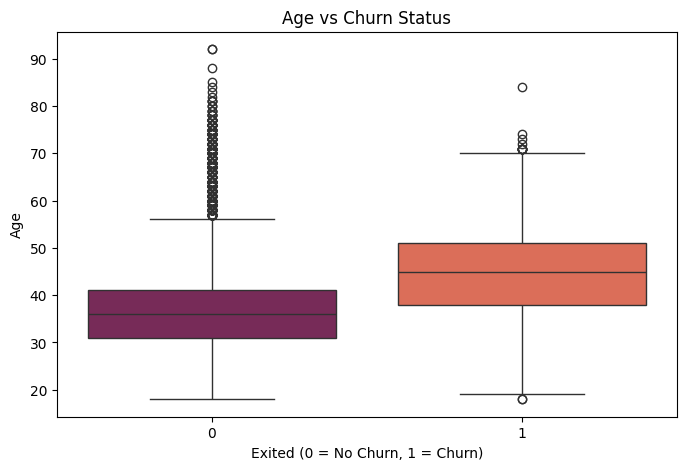

In [7]:
plt.figure(figsize=(10, 6))
sns.histplot(x='Age', hue='Exited', data=df, kde=True, palette='magma')
plt.title('Age Distribution by Churn Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x='Exited', y='Age', data=df, palette='rocket')
plt.title('Age vs Churn Status')
plt.xlabel('Exited (0 = No Churn, 1 = Churn)')
plt.ylabel('Age')
plt.show()

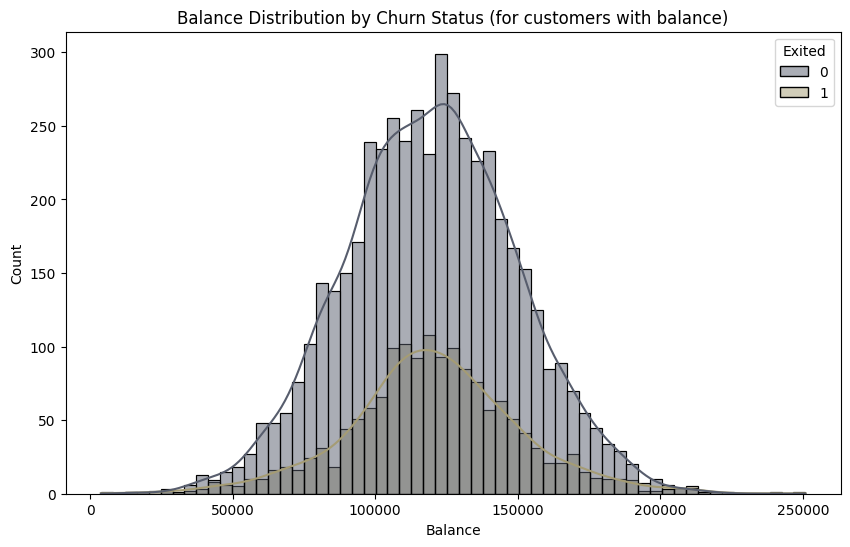

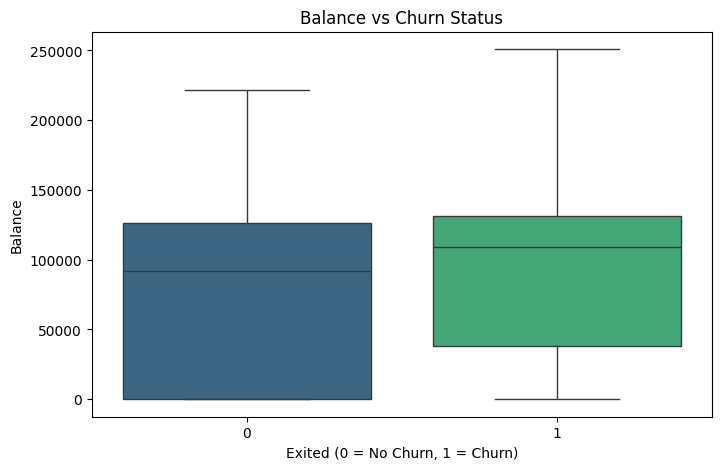

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(x='Balance', hue='Exited', data=df[df['Balance'] > 0], kde=True, palette='cividis')
plt.title('Balance Distribution by Churn Status (for customers with balance)')
plt.xlabel('Balance')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x='Exited', y='Balance', data=df, palette='viridis')
plt.title('Balance vs Churn Status')
plt.xlabel('Exited (0 = No Churn, 1 = Churn)')
plt.ylabel('Balance')
plt.show()

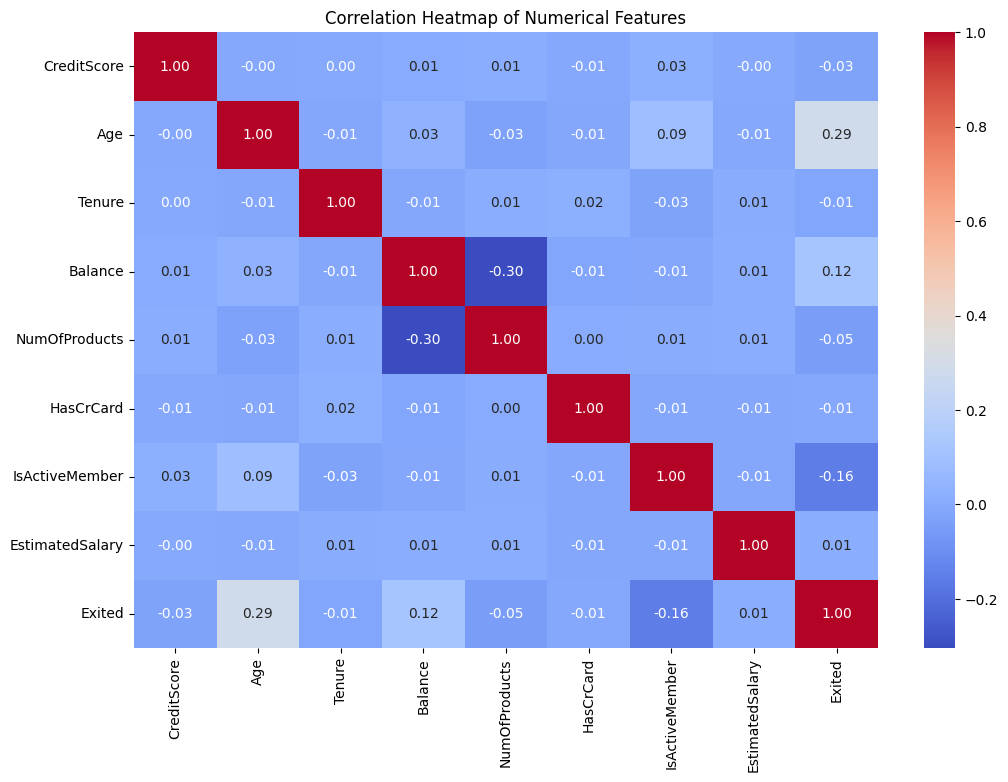

In [9]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.drop(columns=['RowNumber', 'CustomerId', 'Surname']).corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### EDA Insights:
- **Churn Imbalance**: The dataset is imbalanced, with a significantly higher number of customers not churning compared to those who churn (around 20% churn rate).
- **Gender**: Female customers show a slightly higher churn rate compared to male customers.
- **Geography**: Customers from Germany have a considerably higher churn rate than those from France and Spain.
- **Age**: Customers in older age groups (e.g., 40-60) appear to have a higher propensity to churn. The distribution of age for churned customers seems to be shifted towards higher ages.
- **Balance**: Customers with a higher bank balance, particularly those with a balance, seem more likely to churn. Interestingly, customers with zero balance have a lower churn rate, possibly indicating they are not actively using the bank's services anyway.
- **Correlation**: Age and Balance show some positive correlation with `Exited`. `IsActiveMember` shows a negative correlation, suggesting inactive members are more likely to churn.

## 4. Data Preprocessing
This section prepares the raw data for machine learning models by handling irrelevant columns, encoding categorical features, and scaling numerical features.

In [10]:
X = df.drop(['RowNumber', 'CustomerId', 'Surname', 'Exited'], axis=1)
y = df['Exited']

categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(exclude=['object']).columns

print(f"Categorical features: {list(categorical_features)}")
print(f"Numerical features: {list(numerical_features)}")

numerical_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)

print("Preprocessing pipeline created successfully.")

Categorical features: ['Geography', 'Gender']
Numerical features: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
Preprocessing pipeline created successfully.


## 5. Train-Test Split
The dataset is split into training and testing sets to evaluate model performance on unseen data. A stratified split is used to maintain the proportion of churned customers in both sets.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nChurn distribution in training set:")
print(y_train.value_counts(normalize=True))

print("\nChurn distribution in testing set:")
print(y_test.value_counts(normalize=True))

X_train shape: (8000, 10)
X_test shape: (2000, 10)
y_train shape: (8000,)
y_test shape: (2000,)

Churn distribution in training set:
Exited
0    0.79625
1    0.20375
Name: proportion, dtype: float64

Churn distribution in testing set:
Exited
0    0.7965
1    0.2035
Name: proportion, dtype: float64


## 6. Model Training
This section involves training different machine learning models and evaluating their performance using various metrics.

In [12]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear'),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

metrics = pd.DataFrame(columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'])
predictions = {}
probabilities = {}

print("Starting model training...")

for name, model in models.items():
    print(f"\nTraining {name}...")
    full_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                    ('classifier', model)])

    full_pipeline.fit(X_train, y_train)

    y_pred = full_pipeline.predict(X_test)
    y_proba = full_pipeline.predict_proba(X_test)[:, 1]

    predictions[name] = y_pred
    probabilities[name] = y_proba

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    metrics = pd.concat([metrics, pd.DataFrame([{'Model': name, 'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1-Score': f1, 'ROC-AUC': roc_auc}])], ignore_index=True)

    print(f"{name} - Accuracy: {accuracy:.4f}, ROC-AUC: {roc_auc:.4f}")

print("\nAll models trained and evaluated.")

Starting model training...

Training Logistic Regression...
Logistic Regression - Accuracy: 0.8080, ROC-AUC: 0.7748

Training Random Forest...
Random Forest - Accuracy: 0.8575, ROC-AUC: 0.8464

Training Gradient Boosting...
Gradient Boosting - Accuracy: 0.8690, ROC-AUC: 0.8702

All models trained and evaluated.


## 7. Model Evaluation
Detailed evaluation of each model using classification reports and confusion matrices.


Model Evaluation Reports:

--- Logistic Regression ---
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000

Confusion Matrix:


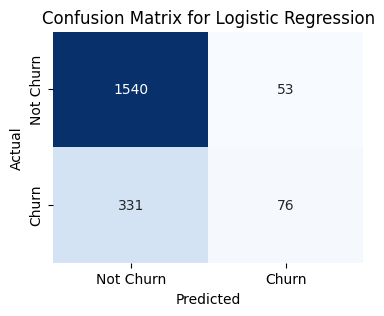


--- Random Forest ---
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.76      0.43      0.55       407

    accuracy                           0.86      2000
   macro avg       0.82      0.70      0.73      2000
weighted avg       0.85      0.86      0.84      2000

Confusion Matrix:


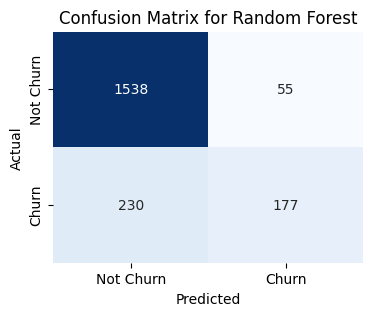


--- Gradient Boosting ---
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1593
           1       0.78      0.49      0.61       407

    accuracy                           0.87      2000
   macro avg       0.83      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000

Confusion Matrix:


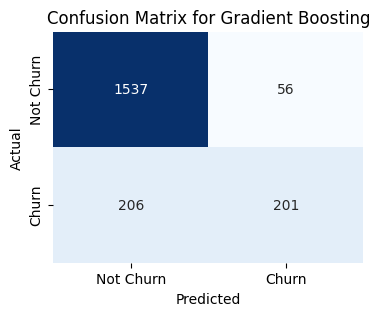

In [13]:
print("\nModel Evaluation Reports:")
for name, y_pred in predictions.items():
    print(f"\n--- {name} ---")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    print("Confusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Not Churn', 'Churn'], yticklabels=['Not Churn', 'Churn'])
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

## 8. Visualization of Model Performance
Visualizing key performance indicators to easily compare models.

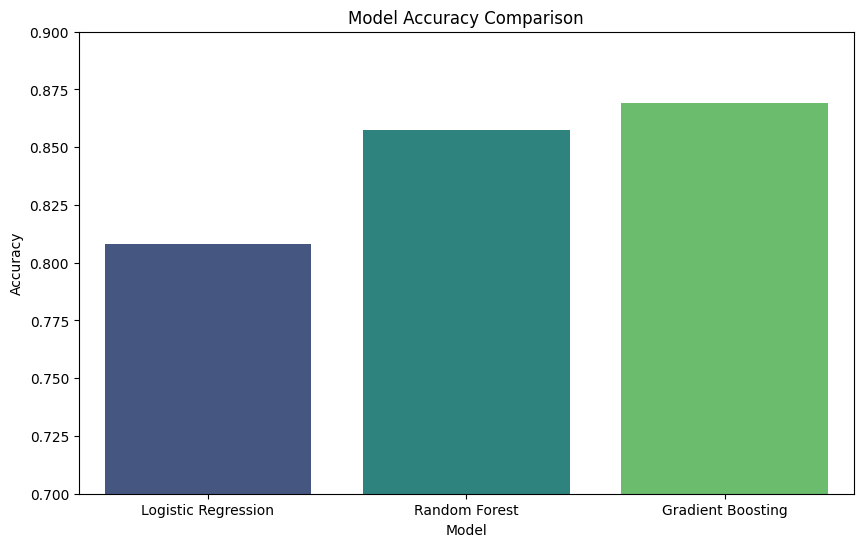

In [14]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=metrics, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.ylim(0.7, 0.9)
plt.ylabel('Accuracy')
plt.show()

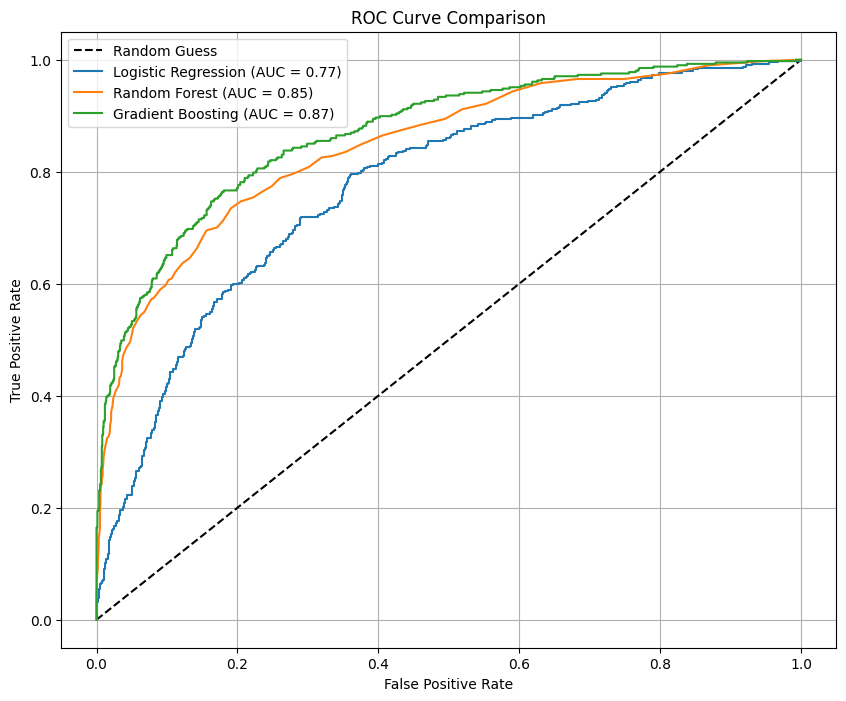

In [15]:
plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

for name, y_proba in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_test, y_proba):.2f})')

plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()

## 9. Model Comparison and Best Model Identification
This section summarizes the performance of all trained models and identifies the best-performing one based on ROC-AUC score.

In [16]:
print("\n--- Model Comparison Table ---")
display(metrics.set_index('Model').sort_values(by='ROC-AUC', ascending=False))

best_model_name = metrics.loc[metrics['ROC-AUC'].idxmax()]['Model']
print(f"\nThe best model based on ROC-AUC score is: **{best_model_name}**")

best_full_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                    ('classifier', models[best_model_name])])
best_full_pipeline.fit(X_train, y_train)

print("Best model pipeline (including preprocessor) saved to 'best_full_pipeline' variable.")


--- Model Comparison Table ---


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Gradient Boosting,0.8690,0.782101,0.493857,0.605422,0.870218
Random Forest,0.8575,0.762931,0.434889,0.553991,0.846374
Logistic Regression,0.8080,0.589147,0.186732,0.283582,0.774766



The best model based on ROC-AUC score is: **Gradient Boosting**
Best model pipeline (including preprocessor) saved to 'best_full_pipeline' variable.


## 10. Prediction System
Creating a function that takes customer details as input, preprocesses them, and predicts churn status along with a confidence score.

In [17]:
def predict_customer_churn(customer_data: dict, model_pipeline: Pipeline) -> dict:
    input_df = pd.DataFrame([customer_data])

    churn_proba = model_pipeline.predict_proba(input_df)[0][1]

    churn_prediction = model_pipeline.predict(input_df)[0]

    prediction_status = 'Churn' if churn_prediction == 1 else 'No Churn'
    confidence_score = churn_proba if churn_prediction == 1 else (1 - churn_proba)

    return {
        'Prediction': prediction_status,
        'Confidence Score': f"{confidence_score:.2f}"
    }

print("Prediction function 'predict_customer_churn' created.")

example_customer = {
    'CreditScore': 600,
    'Geography': 'France',
    'Gender': 'Male',
    'Age': 40,
    'Tenure': 3,
    'Balance': 60000.0,
    'NumOfProducts': 2,
    'HasCrCard': 1,
    'IsActiveMember': 1,
    'EstimatedSalary': 50000.0
}

example_prediction = predict_customer_churn(example_customer, best_full_pipeline)
print("\nExample Prediction for a new customer:")
print(example_prediction)

likely_churn_customer = {
    'CreditScore': 700,
    'Geography': 'Germany',
    'Gender': 'Female',
    'Age': 55,
    'Tenure': 2,
    'Balance': 120000.0,
    'NumOfProducts': 1,
    'HasCrCard': 1,
    'IsActiveMember': 0,
    'EstimatedSalary': 80000.0
}

likely_churn_prediction = predict_customer_churn(likely_churn_customer, best_full_pipeline)
print("\nExample Prediction for a likely churner:")
print(likely_churn_prediction)

Prediction function 'predict_customer_churn' created.

Example Prediction for a new customer:
{'Prediction': 'No Churn', 'Confidence Score': '0.95'}

Example Prediction for a likely churner:
{'Prediction': 'Churn', 'Confidence Score': '0.94'}


## 11. Save Models and Preprocessing Components
Saving the best model, scaler, and the entire preprocessing pipeline for future use without retraining.

In [18]:
joblib.dump(best_full_pipeline, 'best_model_pipeline.joblib')

joblib.dump(preprocessor, 'preprocessing_pipeline.joblib')




model_metadata = {
    'best_model_name': best_model_name,
    'metrics': metrics.to_dict(orient='records'),
    'trained_features': list(X_train.columns),
    'categorical_features': list(categorical_features),
    'numerical_features': list(numerical_features)
}
joblib.dump(model_metadata, 'model_metadata.joblib')

print("Models and preprocessing components saved successfully:")
print("- best_model_pipeline.joblib")
print("- preprocessing_pipeline.joblib")
print("- model_metadata.joblib")

Models and preprocessing components saved successfully:
- best_model_pipeline.joblib
- preprocessing_pipeline.joblib
- model_metadata.joblib


## 12. Final Project Summary
A comprehensive report summarizing the project, including key findings and potential future improvements.

In [19]:
print("--- Customer Churn Prediction Project Summary ---")
print(f"\n1. Dataset Size: {df.shape[0]} rows, {df.shape[1]} columns")

churn_percentage = df['Exited'].value_counts(normalize=True) * 100
print(f"2. Churn Percentage: {churn_percentage[1]:.2f}% of customers churned ({churn_percentage[0]:.2f}% did not churn).")

print("\n3. Models Trained and Compared:")
for index, row in metrics.iterrows():
    print(f"   - {row['Model']}: Accuracy={row['Accuracy']:.4f}, ROC-AUC={row['ROC-AUC']:.4f}")

print(f"\n4. Best Model Identified: **{best_model_name}**")
best_model_metrics = metrics[metrics['Model'] == best_model_name].iloc[0]
print("   Performance Metrics of Best Model:")
print(f"   - Accuracy: {best_model_metrics['Accuracy']:.4f}")
print(f"   - Precision: {best_model_metrics['Precision']:.4f}")
print(f"   - Recall: {best_model_metrics['Recall']:.4f}")
print(f"   - F1-Score: {best_model_metrics['F1-Score']:.4f}")
print(f"   - ROC-AUC: {best_model_metrics['ROC-AUC']:.4f}")

print("\n5. Key Business Insights:")
print("   - **Customer churn is imbalanced** (approx. 20% churn rate), indicating a need for strategies to retain customers.")
print("   - **Geography is a significant factor**, with German customers having a notably higher churn rate. This suggests region-specific issues or competitive pressures.")
print("   - **Age plays a role**, with older customers showing a higher likelihood of churning. Tailored services or loyalty programs for this demographic could be beneficial.")
print("   - **Balance and Inactivity**: Customers with higher balances and those identified as inactive members are more prone to churn. Engaging inactive members and understanding the needs of high-balance customers are crucial.")
print("   - **Gender** showed a slight difference in churn rates, with females having a marginally higher rate.")

print("\n6. Future Improvements:")
print("   - **Hyperparameter Tuning**: Optimize model parameters (e.g., using GridSearchCV or RandomizedSearchCV) for even better performance.")
print("   - **Advanced Feature Engineering**: Explore creating more sophisticated features, such as interaction terms or polynomial features.")
print("   - **More Models**: Experiment with other advanced models like XGBoost, LightGBM, or neural networks.")
print("   - **Anomaly Detection**: Investigate potential outliers in customer behavior that might precede churn.")
print("   - **Explainable AI (XAI)**: Use techniques like SHAP or LIME to get deeper insights into individual predictions and feature contributions.")
print("   - **Deployment**: Deploy the model as a microservice for real-time predictions.")
print("   - **Real-time Data**: Incorporate streaming data for more up-to-date churn predictions.")

--- Customer Churn Prediction Project Summary ---

1. Dataset Size: 10000 rows, 14 columns
2. Churn Percentage: 20.37% of customers churned (79.63% did not churn).

3. Models Trained and Compared:
   - Logistic Regression: Accuracy=0.8080, ROC-AUC=0.7748
   - Random Forest: Accuracy=0.8575, ROC-AUC=0.8464
   - Gradient Boosting: Accuracy=0.8690, ROC-AUC=0.8702

4. Best Model Identified: **Gradient Boosting**
   Performance Metrics of Best Model:
   - Accuracy: 0.8690
   - Precision: 0.7821
   - Recall: 0.4939
   - F1-Score: 0.6054
   - ROC-AUC: 0.8702

5. Key Business Insights:
   - **Customer churn is imbalanced** (approx. 20% churn rate), indicating a need for strategies to retain customers.
   - **Geography is a significant factor**, with German customers having a notably higher churn rate. This suggests region-specific issues or competitive pressures.
   - **Age plays a role**, with older customers showing a higher likelihood of churning. Tailored services or loyalty programs for t